In [ ]:
import cv2
import numpy as np 
import torch
import matplotlib.pyplot as plt
import io
from PIL import Image, ImageFilter

In [ ]:
"""
Takes an image from self.images[path] and modifies it with gaussian noise, returning the new path.
It needs to read/write directly from self.images[path] so that the other code, which reads from there, works.
The rest of the loop in the eval function will overwrite this again with the original image.
"""
def transform_image_noise(img, sigma=7.):
    # Grab image as NumPy array

    # Generate Gaussian noise
    noise = np.random.normal(loc=0.0, scale=sigma, size=img.shape)

    # Add noise
    noisy_img = img + noise

    # Clip to valid range and convert back
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    # Get new path

    # Write back

    return noisy_img

def transform_image_blur(img, sigma=0.8):
    pil_img = Image.fromarray(img)
    blurred = pil_img.filter(ImageFilter.GaussianBlur(radius=sigma))
    return np.array(blurred)

"""
Takes an image from self.images[path] and modifies it with JPEG compression, returning the new path.
It needs to read/write directly from self.images[path] so that the other code, which reads from there, works.
The rest of the loop in the eval function will overwrite this again with the original image.
"""
def transform_image_jpeg(img, quality=70):

    # Convert float images to uint8 safely
    if img.dtype != np.uint8:
        img = np.clip(img * 255.0, 0, 255)
        img = img.astype(np.uint8)

    pil_img = Image.fromarray(img)

    buffer = io.BytesIO()
    pil_img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)

    compressed_img = np.array(Image.open(buffer))

    return compressed_img

"""
Takes an image from self.images[path] and modifies it with brightness change, returning the new path.
It needs to read/write directly from self.images[path] so that the other code, which reads from there, works.
The rest of the loop in the eval function will overwrite this again with the original image.
"""
def transform_image_brightness(img, factor=1.20):

    # Adjust brightness
    bright_img = img * factor

    # Clip and convert back
    bright_img = np.clip(bright_img, 0, 255).astype(np.uint8)

    # Get modified path

    # Write back

    return bright_img

"""
Takes an image from self.images[path] and modifies it with contrast change, returning the new path.
It needs to read/write directly from self.images[path] so that the other code, which reads from there, works.
The rest of the loop in the eval function will overwrite this again with the original image.
"""
def transform_image_contrast(img, factor=1.20):

    # Compute mean per channel (or scalar for grayscale)
    mean = img.mean(axis=(0, 1), keepdims=True)

    # Adjust contrast
    contrast_img = (img - mean) * factor + mean

    # Clip and convert back
    contrast_img = np.clip(contrast_img, 0, 255).astype(np.uint8)

    # Write back
    return contrast_img

im = cv2.imread("data/privacy_common/probe/6632_1.jpg")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
im = np.array(im)
noise_img = transform_image_noise(im)
blur_img = transform_image_blur(im)
jpeg_img = transform_image_jpeg(im)
bright_img = transform_image_brightness(im)
cont_img = transform_image_contrast(im)

plt.imshow(im)
plt.title("Original")
plt.show()
plt.imshow(noise_img)
plt.title("Gaussian Noise")
plt.show()
plt.imshow(blur_img)
plt.title("Gaussian Blur")
plt.show()
plt.imshow(jpeg_img)
plt.title("JPEG Compression")
plt.show()
plt.imshow(bright_img)
plt.title("Brightness Shift")
plt.show()
plt.imshow(cont_img)
plt.title("Contrast Shift")
plt.show()

NameError: name 'im' is not defined

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Collect images and titles in order
images = [
    im,
    noise_img,
    blur_img,
    jpeg_img,
    bright_img,
    cont_img
]

titles = [
    "Original",
    "Gaussian Noise",
    "Gaussian Blur",
    "JPEG Compression",
    "Brightness Adjustment",
    "Contrast Adjustment"
]

# Create figure with scientific-style proportions
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(
    2, 3,
    wspace=0.05,
    hspace=0.15
)

for idx, (img, title) in enumerate(zip(images, titles)):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

# Optional: global title for the entire figure
fig.suptitle(
    "Image Transformations and Their Visual Effects",
    fontsize=16,
    y=0.97
)

plt.show()


NameError: name 'im' is not defined

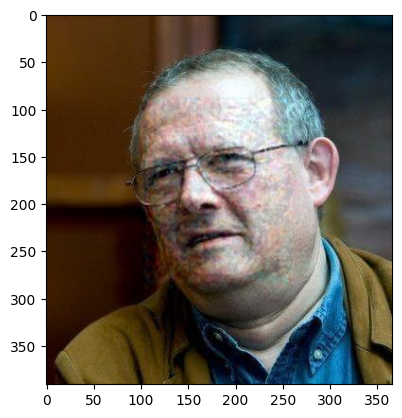

In [ ]:
#im = cv2.imread("data/cloaked/cloak_pubfig_small_flat_Facenet_cosine_pgd_cloak_triplet_10_triplet_10_32_multi_finetune__lpips_50.0_mp_32_p_32/AngelinaJolie_21.jpg")
im = cv2.imread("data/cloaked/cloak_vggface_tiny_flat_multi_finetune_Facenet_cosine_pgd_cloak_multi_triplet_10_16_pgd_cloak_triplet_0_0_2_mse_0.0_none/n000057_006801.jpg")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)

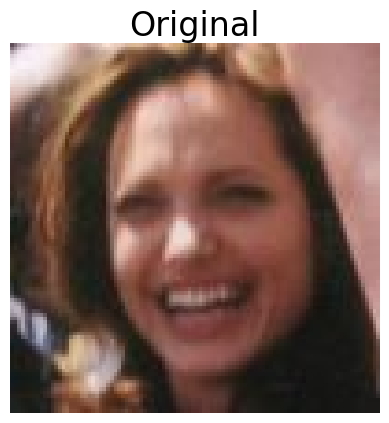

[ WARN:0@1802.473] global loadsave.cpp:268 findDecoder imread_('data/cloaked/cloak_pubfig_small_flat_Facenet_cosine_pgd_cloak_triplet_10_triplet_2_32_multi_finetune__perts_2_32/AngelinaJolie_21.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


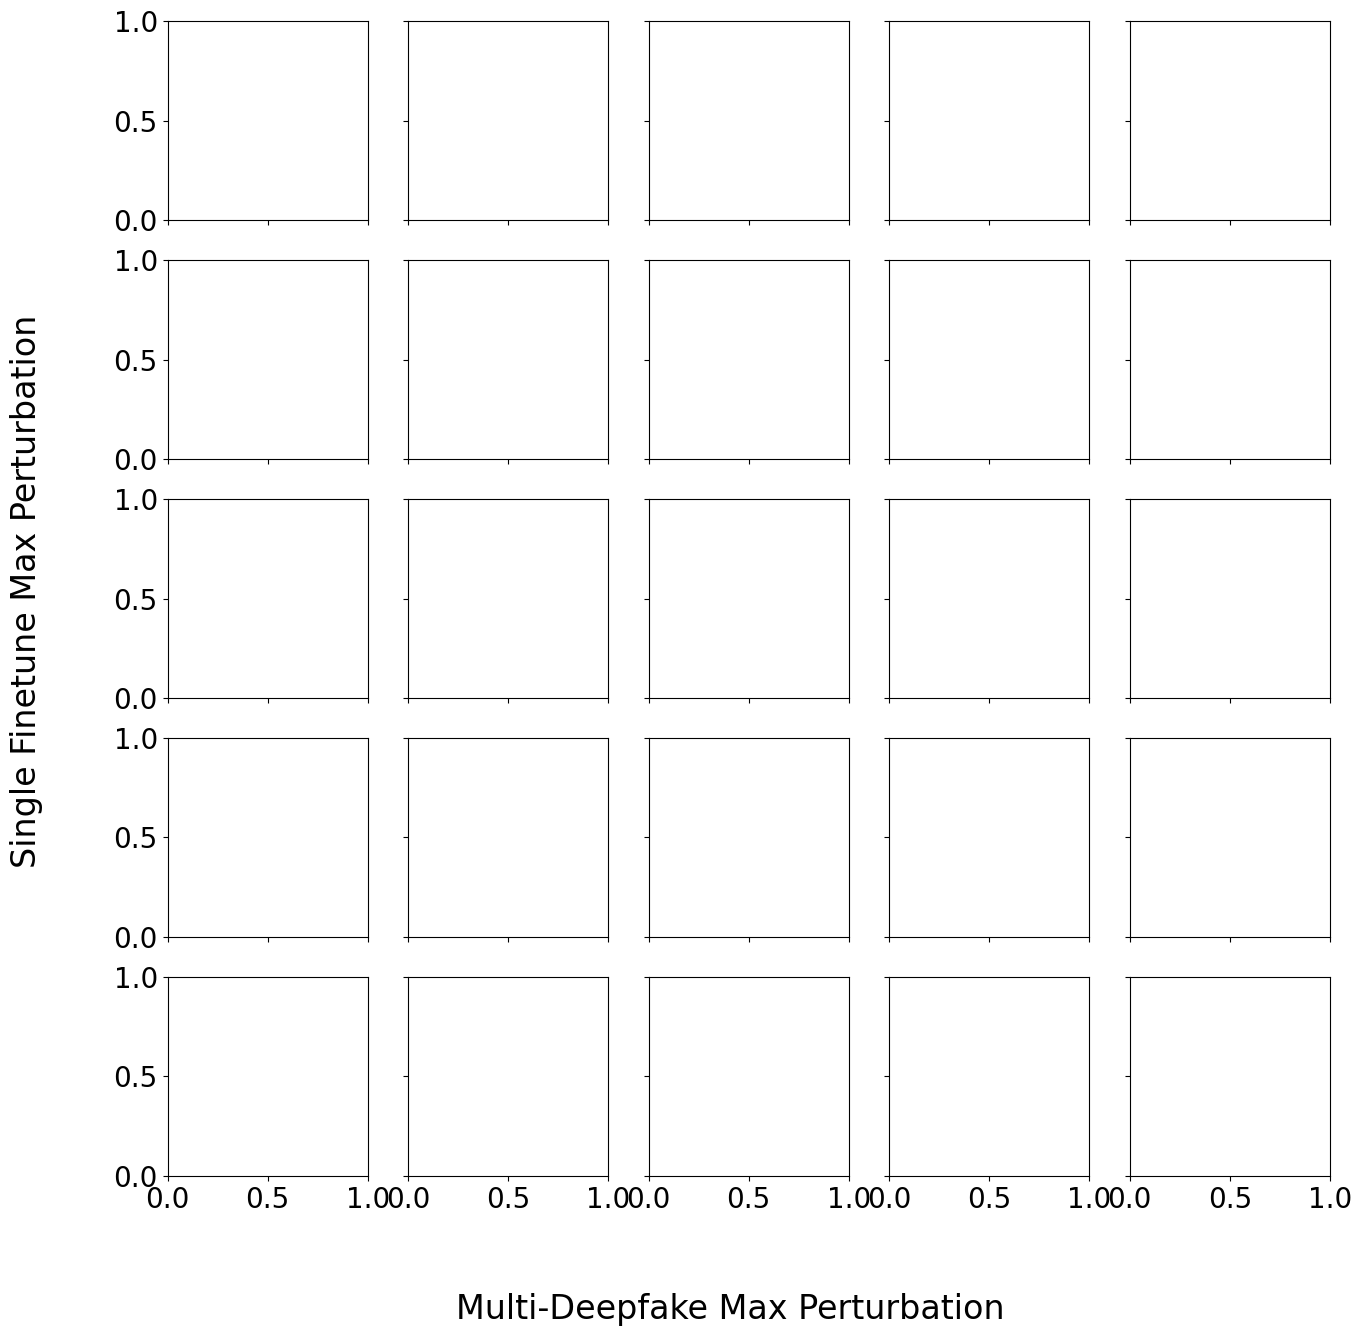

In [ ]:
def parse_type(type):
    data = type.split("_")
    data.pop(2)
    parsed_type=f"dist={data[0]},\noptim={data[1]},\nmulti_loss={data[2]} {data[3]},\nfinetune_loss={data[4]} {data[5]},\n perts={data[6]},\n method={data[7:]}"
    return parsed_type

person = "AngelinaJolie_21.jpg"
dataset = "pubfig_small_flat"
pert_max = ["2", "4", "8", "16", "32"]
multi_max = ["2", "4", "8", "16", "32"]

im = cv2.imread(f"data/{dataset}/{person}")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
plt.axis('off')
plt.title("Original")
plt.show()

plt.rcParams.update({'font.size':20})


fig, ax = plt.subplots(len(pert_max), len(multi_max), sharex='col', sharey='row', figsize=(3*len(pert_max), 3*len(multi_max)))
fig.supylabel("Single Finetune Max Perturbation")
fig.supxlabel("Multi-Deepfake Max Perturbation")
for i, type in enumerate(reversed(pert_max)):
    for j, model in enumerate(multi_max):
        path = f"data/cloaked/cloak_pubfig_small_flat_Facenet_cosine_pgd_cloak_triplet_10_triplet_10_{type}_multi_finetune__perts_{model}_{type}/{person}"
        im = cv2.imread(path)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i,j].imshow(im)
        if i == len(pert_max) - 1:
            ax[i,j].set_xlabel(model)
        if j == 0:
            #ax[i,j].set_ylabel(parse_type(type), rotation=0, labelpad=5, va='center', ha='right')
            ax[i,j].set_ylabel(type)

plt.tight_layout()
plt.show()
